In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Confidence plot functions

In [2]:
results_path = "./LOG/results/"

In [3]:
my_results = pd.read_csv(str(results_path)+"myresults.txt",
                    comment='#',
                    sep="\s+",
                    index_col=False,
                    names=["e", "e_err1", "e_err2", "theta", "theta_err1", "theta_err2", "sigma", "sigma_err1", "sigma_err2", "sys"])
my_results.head()

,e,e_err1,e_err2,theta,theta_err1,theta_err2,sigma,sigma_err1,sigma_err2,sys
0,0.239,0.045,0.061,-2.0,1.6,1.6,434.320,0.300,0.300,1.1
1,0.210,0.026,0.034,0.5,1.4,1.4,434.310,0.300,0.300,1.2
2,1.470,0.530,0.390,161.5,1.8,1.8,498.000,15.000,18.000,2.0
3,1.230,0.150,0.170,54.0,2.8,2.8,547.293,0.012,0.012,3.1
4,0.365,0.078,0.170,53.8,2.4,2.4,479.500,9.300,9.300,3.2


In [4]:
anna_results = pd.read_csv(str(results_path)+"anna_results.txt",
                    comment='#',
                    sep="\s+",
                    index_col=False,
                    names=["e", "e_err", "theta", "theta_err","sigma", "sigma_err", "sys"])
anna_results.head()

,e,e_err,theta,theta_err,sigma,sigma_err,sys
0,0.11,0.008,9.28,1.30,440.58,1.40,1
1,0.08,0.120,4.90,24.95,434.59,2.96,1
2,0.32,0.060,6.41,1.27,442.03,3.26,1
3,0.51,0.000,164.10,0.00,524.00,0.00,2
4,0.51,0.000,164.00,0.00,525.00,8.90,2


In [10]:
params_dict={
    1:"e",
    2:"theta",
    3:"sigma"
}
colorcode={
    0:"green",
    1:"k",
    2:"teal",
    3:"r",
    4:"blue"
}

legend={
    0:"without counter image",
    1:"w/ counter image",
    2:"Anna DS9",
    3:"Anna barycenter",
    4:"Anna Best Bright"
}
param_latex_dict = {
    1:"e",
    2:"θ",
    3:"σ"
}

def confidence_plot(sys):
    # figure
    fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)

    # number of elements in sys
    n = len(my_results["sys"][np.abs(my_results["sys"]-sys) < 0.5])

    systems = my_results["sys"][np.abs(my_results["sys"]-sys) < 0.5]
    systems.reset_index(drop=True, inplace=True)

    for ii in range(1,4):
        ax = fig.add_subplot(1, 3, ii)
        for jj in range(0, len(systems)):
            if ii == 3:
                #print(legend[jj])
                ax.errorbar(my_results[my_results["sys"]==systems[jj]][params_dict[ii]], jj, xerr=np.array([my_results[my_results["sys"]==systems[jj]][str(params_dict[ii])+"_err1"], my_results[my_results["sys"]==systems[jj]][str(params_dict[ii])+"_err2"]]), fmt='o', c=str(colorcode[jj]), label=legend[jj])
            else:
                ax.errorbar(my_results[my_results["sys"]==systems[jj]][params_dict[ii]], jj, xerr=np.array([my_results[my_results["sys"]==systems[jj]][str(params_dict[ii])+"_err1"], my_results[my_results["sys"]==systems[jj]][str(params_dict[ii])+"_err2"]]), fmt='o', c=str(colorcode[jj]))

        sys_anna=sys
        if isinstance(sys, float) == True:
            sys_anna=str(sys)
            sys_anna=int(sys_anna[:-2])

        new_df = anna_results[anna_results["sys"]==sys_anna]
        new_df.reset_index(drop=True, inplace=True)
        for jj in range(0, len(new_df)):
            if ii == 3:
                ax.errorbar(new_df[params_dict[ii]][jj], jj+2, xerr=np.array([[new_df[str(params_dict[ii])+"_err"][jj]], [new_df[str(params_dict[ii])+"_err"][jj]]]), fmt='o', c=str(colorcode[jj+2]), label=legend[jj+2])
            else:
                ax.errorbar(new_df[params_dict[ii]][jj], jj+2, xerr=np.array([[new_df[str(params_dict[ii])+"_err"][jj]], [new_df[str(params_dict[ii])+"_err"][jj]]]), fmt='o', c=str(colorcode[jj+2]))

        plt.xlabel(param_latex_dict[ii])
        plt.yticks([])
        plt.rcParams.update({"font.size": 13})
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5)


# CS82SL013639.16+000818.38

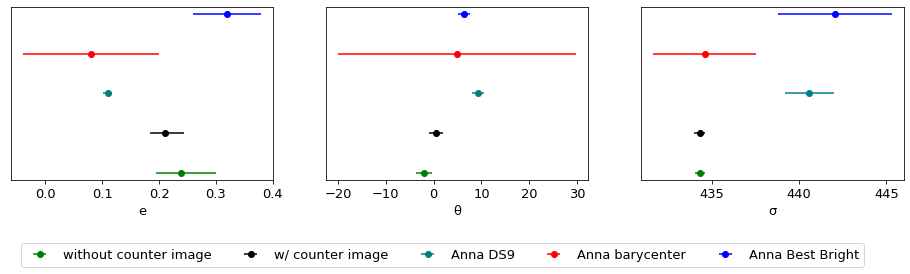

In [11]:
confidence_plot(1)

# CS82SL015824.81-003959.60

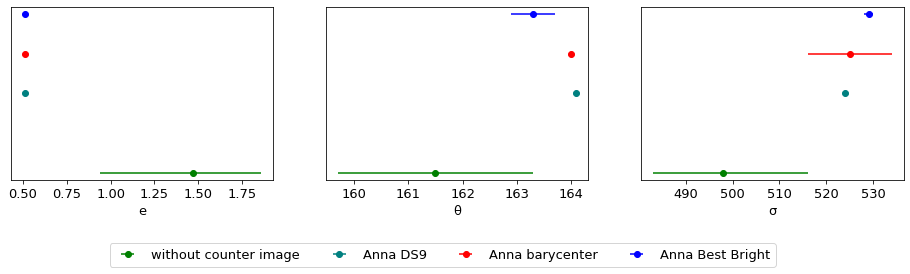

In [12]:
confidence_plot(2)

# CS82SL211527.25-003817.26

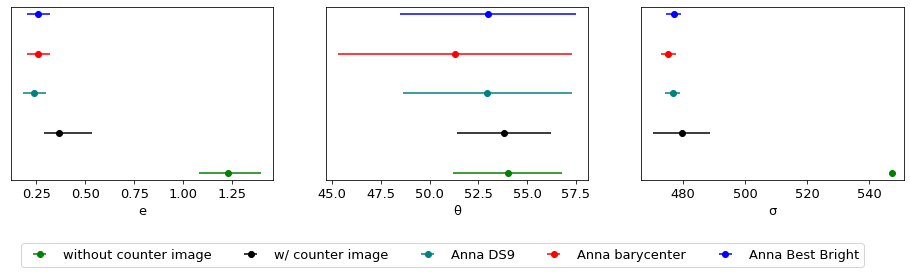

In [13]:
confidence_plot(3)

# CS82SL230521.68-000211.52

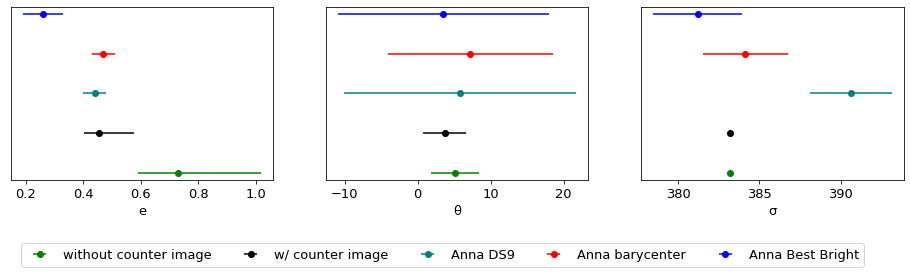

In [14]:
confidence_plot(4)